In [1]:
import pickle
import os
import numpy as np
import networkx as nx
import sys
import pandas as pd
sys.path.append("../../src")
from cell_types_and_gene_utils import get_cell_type_data, plot_classifier_celltype_shap_values,generate_gene_lv_graphs, visualize_gene_lv_graphs, apply_g_profiler,enrichment_bubble_plot_colored

In [2]:
chosen_dataset='Pancreas'
chosen_experiment='results'
dataset_dir=os.path.join('..', chosen_dataset)
read_dir = os.path.join(dataset_dir, chosen_experiment, 'chosen_exp_components')

Classifier Cell Type Analysis

In [3]:
with open(os.path.join(read_dir, 'SHAP_Values_DeepExplainer_1_classifier.pkl'),'rb') as f:
    shap_classifier=pickle.load(f)

with open(os.path.join(read_dir, 'SHAP_Values_DeepExplainer_10_decoder.pkl'),'rb') as f:
    lv_gene_shap_values=pickle.load(f)

with open(os.path.join(read_dir, 'index_to_class.pkl'),'rb') as f:
    index_to_class=pickle.load(f)
    
with open(os.path.join(read_dir, 'active_terms.pkl'), 'rb') as f:
    active_terms=pickle.load(f)

with open(os.path.join(dataset_dir,'gene_names.pkl'),'rb') as f:
    name_genes={key: val for key, val in pickle.load(f).items() if key!="clusters"}


In [4]:
cell_types, index_to_clusters, index_to_all_types, clusters_to_dag, all_to_dag=get_cell_type_data(chosen_dataset)

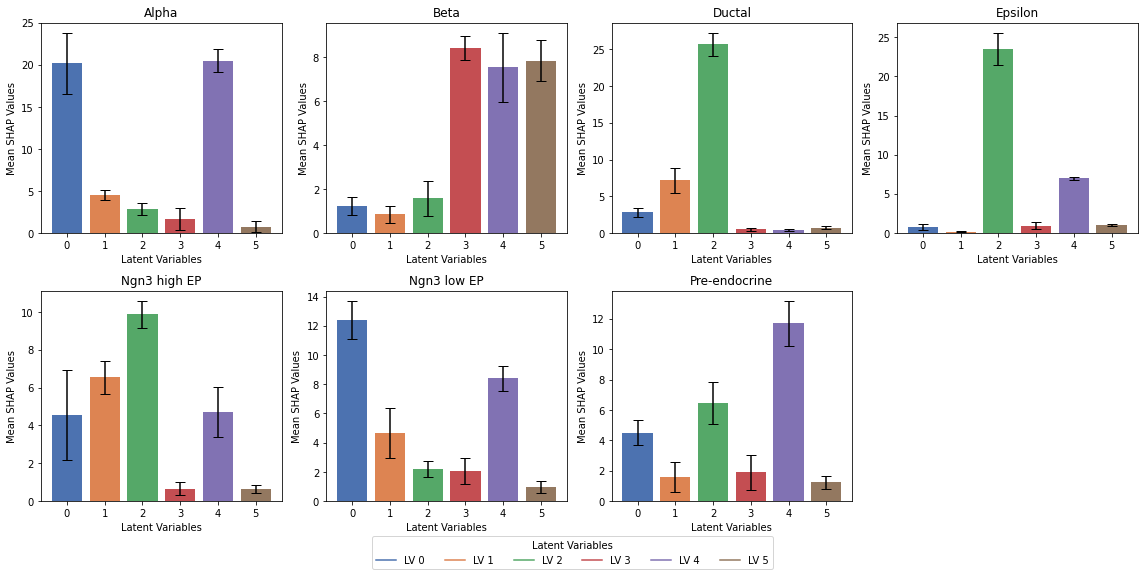

In [5]:
plot_classifier_celltype_shap_values(shap_classifier, index_to_class, index_to_all_types)

Creating a sample instance of gene_lv_network

In [6]:
# top_k_lv = 300
# resolution_gene_lv_network=1.1
# results, shap_netowrks, titles = generate_gene_lv_graphs(
#     lv_gene_shap_values, index_to_class, index_to_clusters, active_terms, name_genes=name_genes, top_k_lv=top_k_lv
# )
# gene_lv_partitions=visualize_gene_lv_graphs(shap_netowrks, titles, resolution_gene_lv_network,index_to_all_types, clusters_to_dag)
# partition_to_list=[{v: {k for k, val in dicts.items() if val == v} for v in set(dicts.values())} for idx, dicts in enumerate(gene_lv_partitions)]
# gene_lv_graphs_df=pd.DataFrame.from_dict({index_to_all_types[idx]:partition_to_list[idx] for idx in range(cell_types)})
# # gene_lv_graphs_df.to_csv(os.path.join(read_dir,'genes_per_cluster_cell_type.csv'))

In [7]:
gene_lv_graphs_df=pd.read_csv(os.path.join(read_dir,'genes_per_cluster_cell_type.csv'),index_col=0)

In [8]:
enrichment_results, map_lv_to_clusters=apply_g_profiler(gene_lv_graphs_df,organism='mmusculus')


  0%|          | 0/4 [00:00<?, ?it/s]

For the current cluster, Number of all cell functions 77,Number of cell functions with less than e-5 p value 16
For the current cluster, Number of all cell functions 158,Number of cell functions with less than e-5 p value 29
For the current cluster, Number of all cell functions 92,Number of cell functions with less than e-5 p value 15


 25%|██▌       | 1/4 [00:14<00:43, 14.54s/it]

For the current cluster, Number of all cell functions 213,Number of cell functions with less than e-5 p value 79
For the current cluster, Number of all cell functions 78,Number of cell functions with less than e-5 p value 9
For the current cluster, Number of all cell functions 112,Number of cell functions with less than e-5 p value 19
For the current cluster, Number of all cell functions 108,Number of cell functions with less than e-5 p value 23


 50%|█████     | 2/4 [00:30<00:30, 15.34s/it]

...

For the current cluster, Number of all cell functions 229,Number of cell functions with less than e-5 p value 75
Error evaluating nan
For the current cluster, Number of all cell functions 173,Number of cell functions with less than e-5 p value 110
For the current cluster, Number of all cell functions 96,Number of cell functions with less than e-5 p value 11
For the current cluster, Number of all cell functions 176,Number of cell functions with less than e-5 p value 38


6it [01:35, 16.08s/it]

For the current cluster, Number of all cell functions 63,Number of cell functions with less than e-5 p value 2
For the current cluster, Number of all cell functions 31,Number of cell functions with less than e-5 p value 6
For the current cluster, Number of all cell functions 155,Number of cell functions with less than e-5 p value 12
For the current cluster, Number of all cell functions 188,Number of cell functions with less than e-5 p value 39


7it [01:49, 15.60s/it]

For the current cluster, Number of all cell functions 184,Number of cell functions with less than e-5 p value 20


../../src\cell_types_and_gene_utils.py:402: UserWarning: FixedFormatter should only be used together with FixedLocator
  bubble_plot.set_xticklabels(bubble_plot.get_xticklabels(), rotation=45)


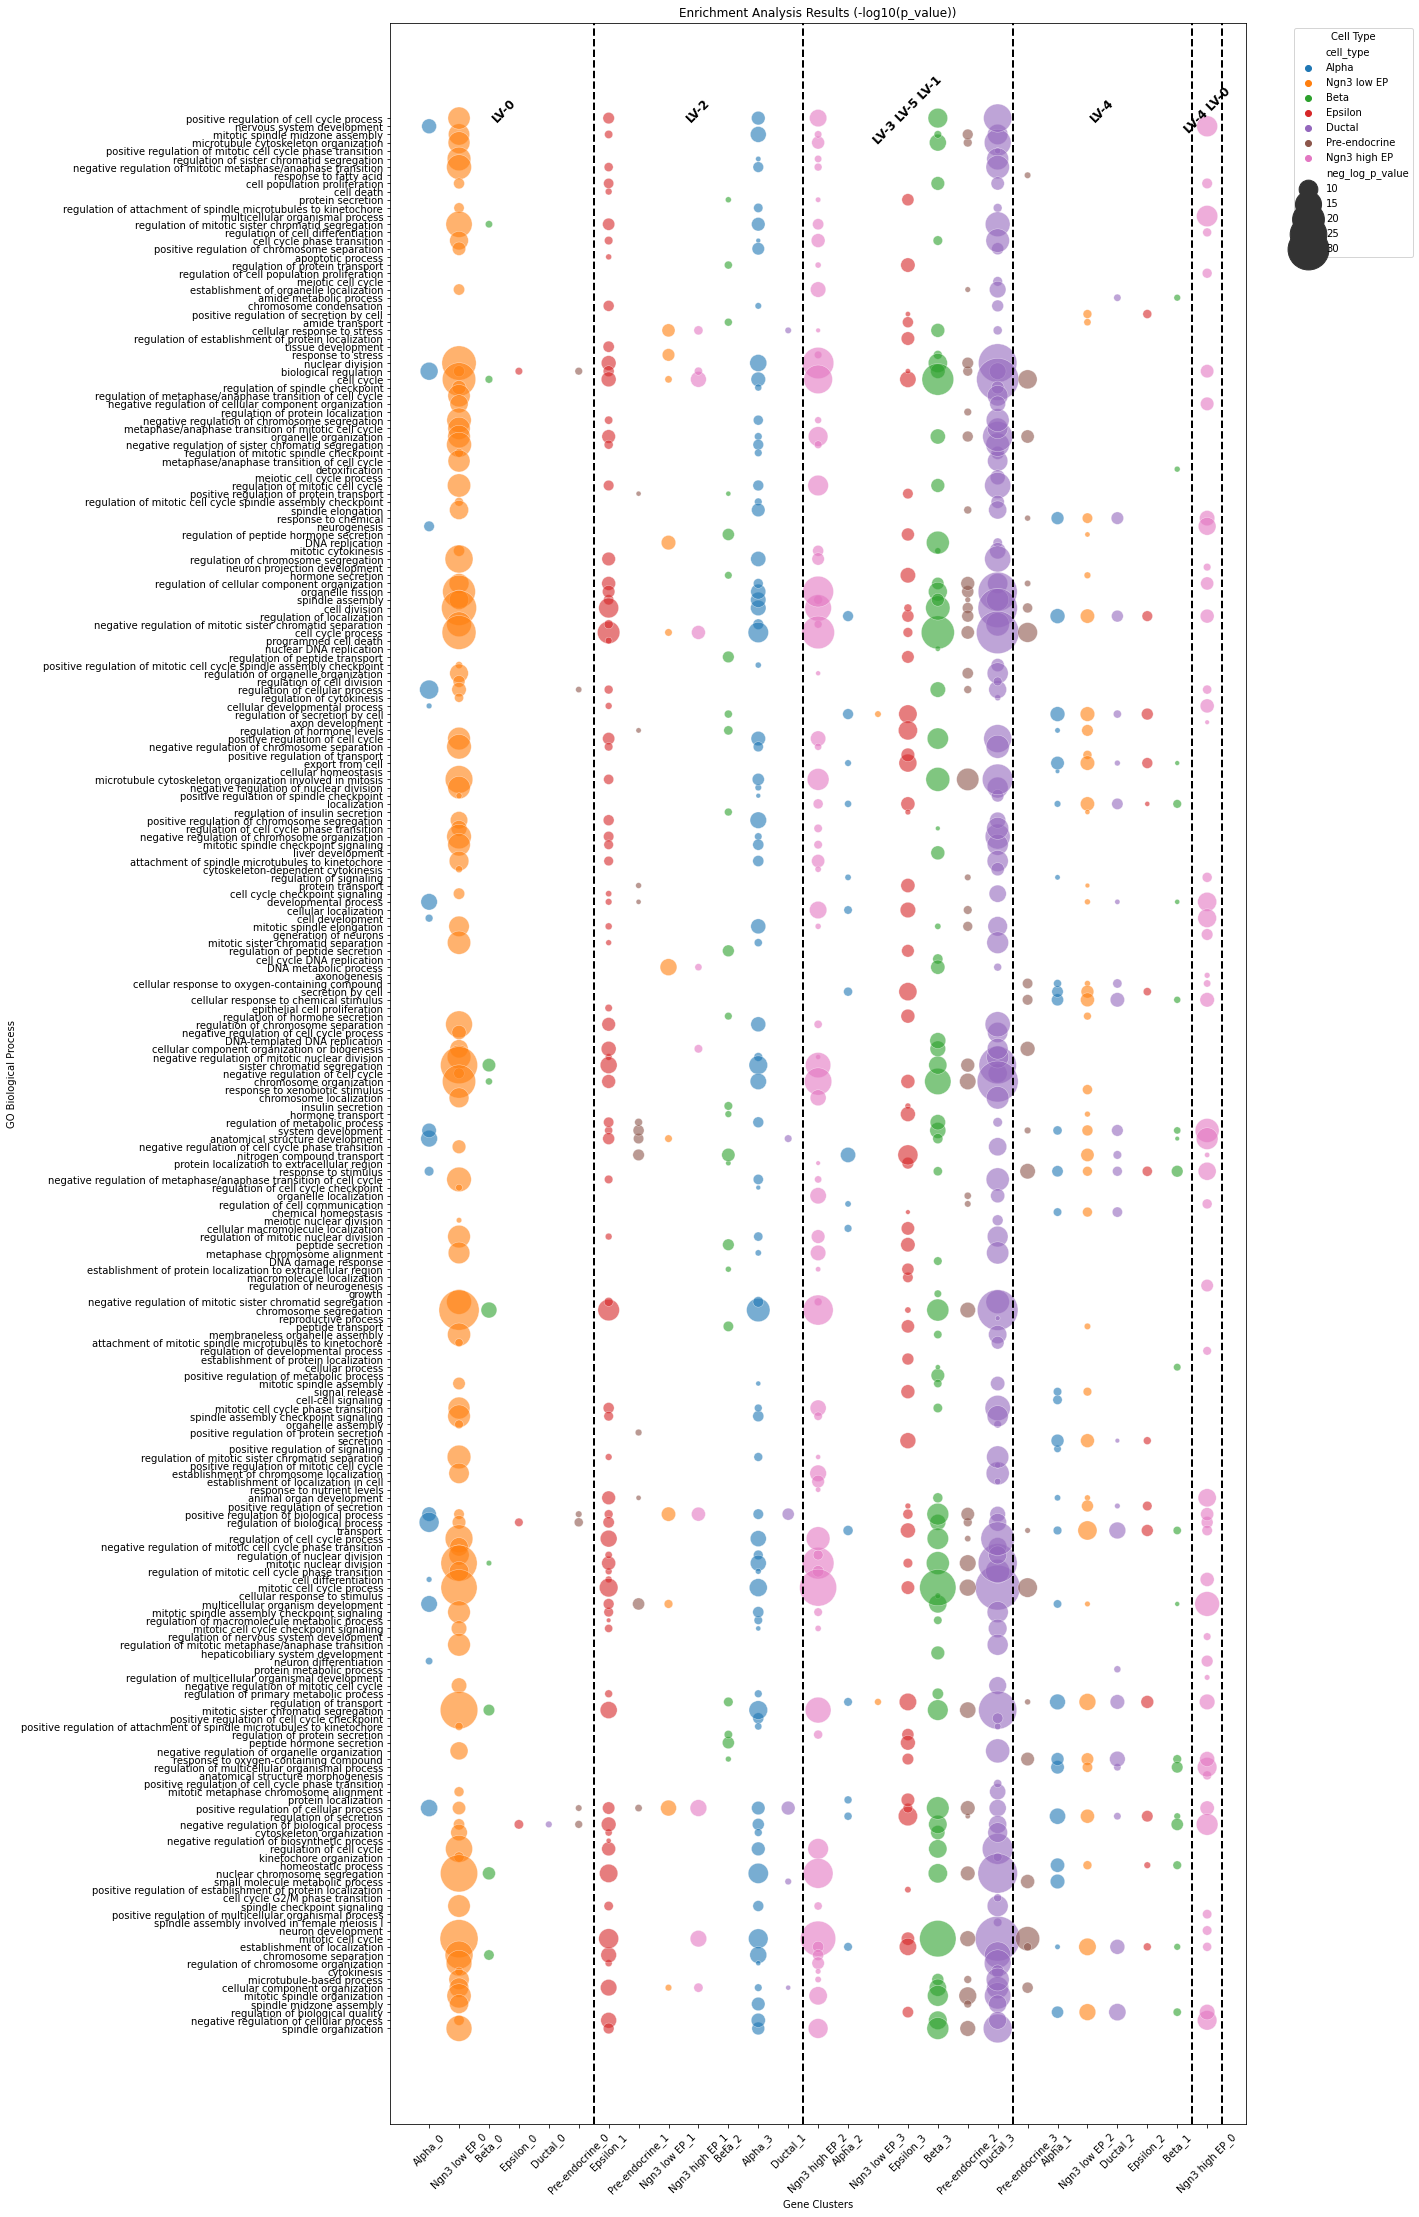

In [9]:
enrichment_bubble_plot_colored(enrichment_results, map_lv_to_clusters)